# Wikipedia Math Essentials Network Project - Manan Kothari

**Project idea:** Use the Wikipedia Math Essentials dataset to study how mathematical topics behave as a directed network.


## Research Questions

1. Which Wikipedia math pages are most central in the directed math knowledge graph?
2. Are structurally central pages also the pages that receive more attention through visits?
3. Do soft clusters reveal overlapping mathematical communities?
4. Do ambiguous pages, meaning pages with low GMM assignment confidence, behave like bridges between areas?
5. Can graph-derived features and SVD embeddings predict average page visits?

In [80]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.sparse import coo_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 1. Load the Dataset

In [81]:

JSON_PATH = Path("wikivital_mathematics.json")

with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

print("Top-level keys:", list(raw.keys())[:20])
print("Has edges:", "edges" in raw)
print("Has weights:", "weights" in raw)
print("Has node_ids:", "node_ids" in raw)
print("Has time_periods:", "time_periods" in raw)

Top-level keys: ['edges', 'weights', 'node_ids', 'time_periods', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
Has edges: True
Has weights: True
Has node_ids: True
Has time_periods: True


## 2. Parse Edges, Weights, Node Names, and Page Visits

In [82]:
edges = np.array(raw["edges"], dtype=int)

if edges.ndim != 2 or edges.shape[1] != 2:
    raise ValueError(f"Expected edges to have shape (E, 2), got {edges.shape}")

weights = np.array(raw.get("weights", np.ones(len(edges))), dtype=float).reshape(-1)

if len(weights) != len(edges):
    raise ValueError(f"weights length {len(weights)} does not match edges length {len(edges)}")

node_ids = raw.get("node_ids", {})
T = int(raw["time_periods"])

visit_rows = []
date_rows = []

for t in range(T):
    snap = raw[str(t)]
    visit_rows.append(snap["y"])
    date_rows.append(pd.Timestamp(
        year=int(snap["year"]),
        month=int(snap["month"]),
        day=int(snap["day"])
    ))

visits = np.array(visit_rows, dtype=float)
dates = pd.DatetimeIndex(date_rows)

N_from_edges = int(edges.max()) + 1
N_from_node_ids = len(node_ids) if isinstance(node_ids, dict) else 0
N_from_visits = visits.shape[1]

N = max(N_from_edges, N_from_node_ids, N_from_visits)

print("edges:", edges.shape)
print("weights:", weights.shape)
print("visits:", visits.shape)
print("dates:", dates.min(), "to", dates.max())
print("N nodes:", N)
print("T time periods:", T)

edges: (27079, 2)
weights: (27079,)
visits: (731, 1068)
dates: 2019-03-16 00:00:00 to 2021-03-15 00:00:00
N nodes: 1068
T time periods: 731


In [83]:
def build_titles(node_ids, N):
    titles = [f"node_{i}" for i in range(N)]

    for title, idx in node_ids.items():
        idx = int(idx)
        if 0 <= idx < N:
            titles[idx] = title

    return titles

titles = build_titles(node_ids, N)

pd.DataFrame({
    "node": range(min(10, N)),
    "title": titles[:10]
})

,node,title
0,0,Mathematics
1,1,Number theory
2,2,Algebra
3,3,Geometry
4,4,Calculus
5,5,Mathematical analysis
6,6,Conjecture
7,7,Mathematical proof
8,8,Counting
9,9,Shape


## 3. Build the Directed Weighted Graph

In [84]:
edges_df = pd.DataFrame({
    "source": edges[:, 0],
    "target": edges[:, 1],
    "weight": weights
})

G = nx.DiGraph()
G.add_nodes_from(range(N))

for s, t, w in edges_df.itertuples(index=False):
    G.add_edge(int(s), int(t), weight=float(w))

print(G)
print("Directed:", G.is_directed())
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

DiGraph with 1068 nodes and 27079 edges
Directed: True
Nodes: 1068
Edges: 27079


## 4. Graph Sanity Checks

In [85]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Directed:", G.is_directed())
print("Self-loops:", nx.number_of_selfloops(G))

isolated = list(nx.isolates(G))
print("Isolated nodes:", len(isolated))

weak_components = list(nx.weakly_connected_components(G))
strong_components = list(nx.strongly_connected_components(G))

print("Weakly connected components:", len(weak_components))
print("Strongly connected components:", len(strong_components))
print("Largest weak component size:", max(len(c) for c in weak_components))
print("Largest strong component size:", max(len(c) for c in strong_components))

Nodes: 1068
Edges: 27079
Directed: True
Self-loops: 0
Isolated nodes: 0
Weakly connected components: 1
Strongly connected components: 1068
Largest weak component size: 1068
Largest strong component size: 1


## 5. PageRank

In [86]:
pagerank = nx.pagerank(G, alpha=0.85, weight="weight")


hubs, authorities = nx.hits(G, max_iter=1000, normalized=True)

node_df = pd.DataFrame({
    "node": range(N),
    "title": titles,
    "in_degree": [G.in_degree(i) for i in range(N)],
    "out_degree": [G.out_degree(i) for i in range(N)],
    "weighted_in_degree": [G.in_degree(i, weight="weight") for i in range(N)],
    "weighted_out_degree": [G.out_degree(i, weight="weight") for i in range(N)],
    "pagerank": [pagerank[i] for i in range(N)],
    "hub_score": [hubs[i] for i in range(N)],
    "authority_score": [authorities[i] for i in range(N)]
})

print("PageRank sum:", node_df["pagerank"].sum())
node_df.sort_values("pagerank", ascending=False).head(20)

PageRank sum: 0.9999999999999998


,node,title,in_degree,out_degree,weighted_in_degree,weighted_out_degree,pagerank,hub_score,authority_score
996,996,Rotations in 4-dimensional Euclidean space,14,0,16.0,0.0,0.009516,-0.000000,0.000405
989,989,24-cell,29,1,79.0,1.0,0.008917,0.000007,0.000281
906,906,Symmetric relation,25,3,34.0,3.0,0.006492,0.000006,0.000223
980,980,Branch point,26,0,31.0,0.0,0.005890,-0.000000,0.000455
976,976,Queue (abstract data type),25,0,34.0,0.0,0.005472,-0.000000,0.000040
959,959,Lambert W function,28,2,29.0,2.0,0.005137,0.000016,0.000545
1013,1013,Duality (optimization),10,0,12.0,0.0,0.005083,-0.000000,0.000052
917,917,Elliptic partial differential equation,14,0,16.0,0.0,0.004958,-0.000000,0.000111
761,761,10,29,2,41.0,2.0,0.004797,0.000007,0.000415
1000,1000,Bucket sort,17,0,32.0,0.0,0.004703,-0.000000,0.000036


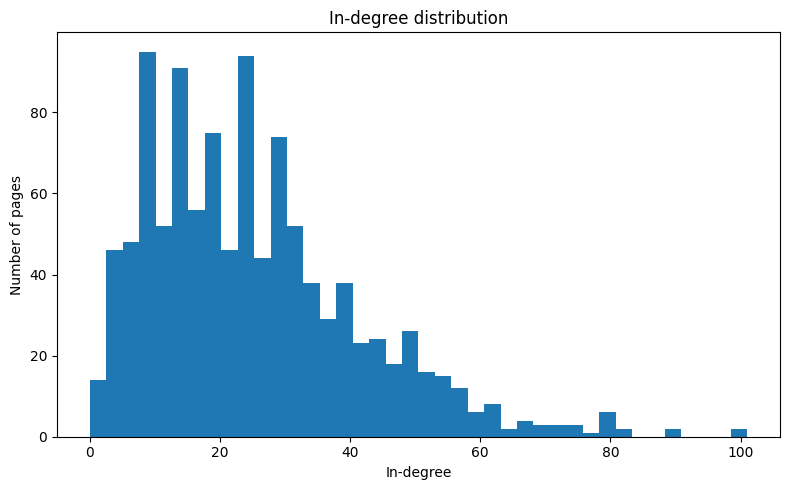

In [87]:
plt.figure(figsize=(8, 5))
plt.hist(node_df["in_degree"], bins=40)
plt.xlabel("In-degree")
plt.ylabel("Number of pages")
plt.title("In-degree distribution")
plt.tight_layout()
plt.show()

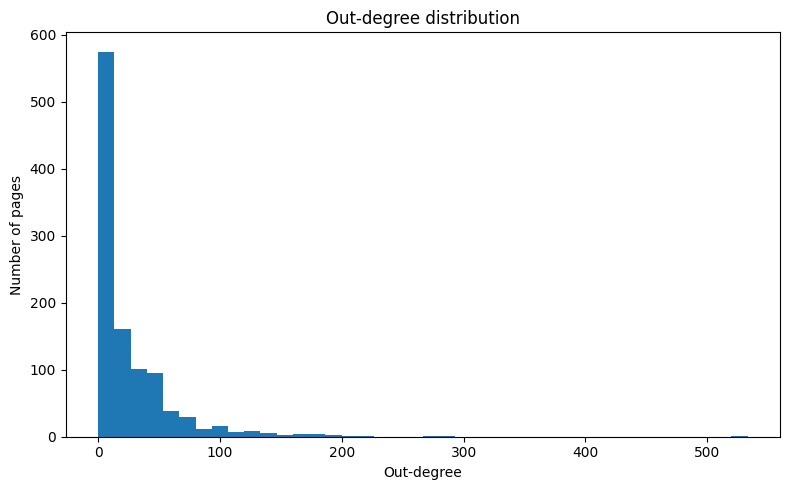

In [88]:
plt.figure(figsize=(8, 5))
plt.hist(node_df["out_degree"], bins=40)
plt.xlabel("Out-degree")
plt.ylabel("Number of pages")
plt.title("Out-degree distribution")
plt.tight_layout()
plt.show()

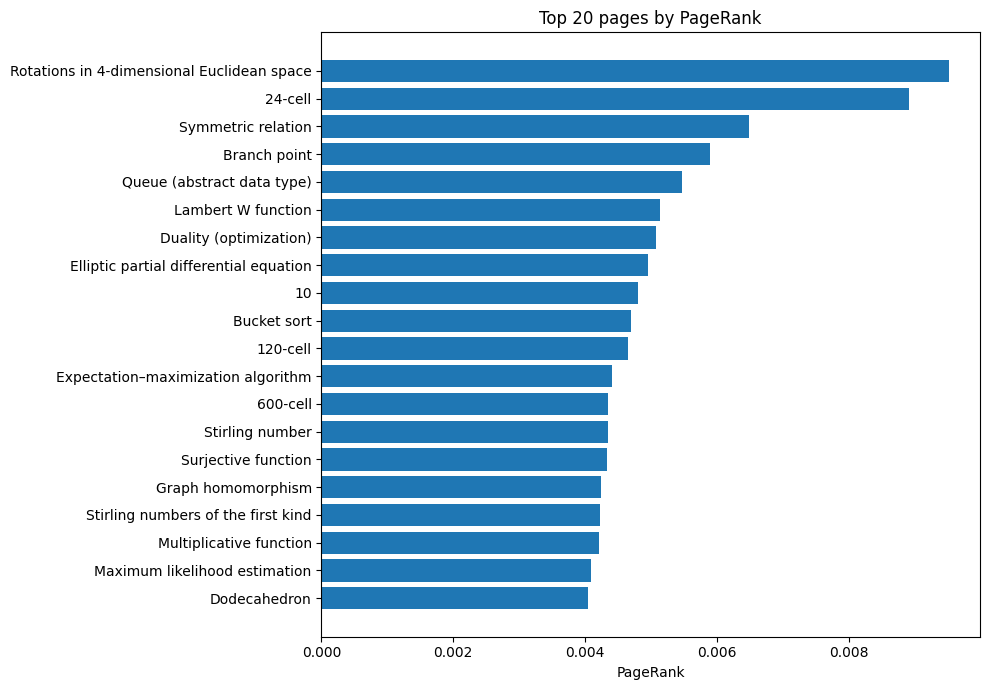

In [89]:
top_pr = node_df.nlargest(20, "pagerank").sort_values("pagerank")

plt.figure(figsize=(10, 7))
plt.barh(top_pr["title"], top_pr["pagerank"])
plt.xlabel("PageRank")
plt.title("Top 20 pages by PageRank")
plt.tight_layout()
plt.show()

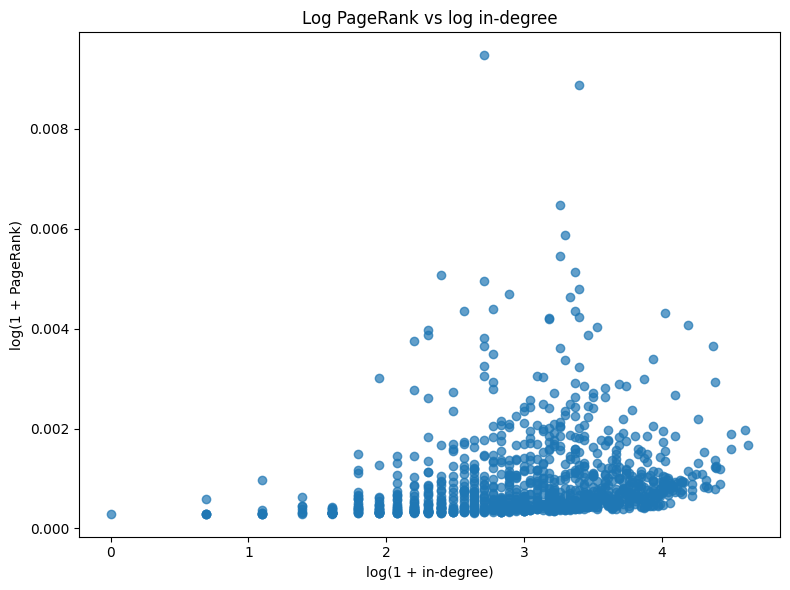

In [90]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log1p(node_df["in_degree"]), np.log1p(node_df["pagerank"]), alpha=0.7)
plt.xlabel("log(1 + in-degree)")
plt.ylabel("log(1 + PageRank)")
plt.title("Log PageRank vs log in-degree")
plt.tight_layout()
plt.show()

## 6. Page-Visit Features

In [ ]:


visits_df = pd.DataFrame(
    visits,
    index=dates,
    columns=[f"node_{i}" for i in range(N)]
)

x = np.arange(T)
x_centered = x - x.mean()
visits_centered = visits - visits.mean(axis=0)
slopes = (x_centered[:, None] * visits_centered).sum(axis=0) / (x_centered ** 2).sum()

time_df = pd.DataFrame({
    "node": range(N),
    "mean_visits": visits.mean(axis=0),
    "median_visits": np.median(visits, axis=0),
    "std_visits": visits.std(axis=0),
    "max_visits": visits.max(axis=0),
    "total_visits": visits.sum(axis=0),
    "visit_slope": slopes
})

node_df = node_df.merge(time_df, on="node")

node_df.sort_values("mean_visits", ascending=False).head(20)

,node,title,in_degree,out_degree,weighted_in_degree,weighted_out_degree,pagerank,hub_score,authority_score,mean_visits,median_visits,std_visits,max_visits,total_visits,visit_slope
417,417,Normal distribution,30,52,31.0,119.0,0.000534,0.001247,0.000846,7325.607387,7209.0,2063.213190,11985.0,5355019.0,0.724953
422,422,Standard deviation,17,52,23.0,80.0,0.000391,0.000725,0.000374,7019.425445,7241.0,2126.127998,18157.0,5131200.0,-1.599616
575,575,Fibonacci number,48,30,67.0,34.0,0.001490,0.000336,0.000938,6190.116279,6124.0,1210.797512,13667.0,4524975.0,2.301218
22,22,Pi,10,125,14.0,177.0,0.000313,0.005166,0.000793,5119.181943,4631.0,3288.533070,68633.0,3742122.0,2.958554
484,484,Roman numerals,12,16,17.0,23.0,0.000427,0.000308,0.000478,5102.829001,4916.0,1301.657152,24864.0,3730168.0,1.898230
33,33,Prime number,11,159,15.0,258.0,0.000322,0.006116,0.000696,4607.626539,4184.0,1467.645073,14474.0,3368175.0,4.040338
881,881,Poisson distribution,38,8,55.0,15.0,0.001388,0.000086,0.000521,4481.580027,4323.0,1414.554596,7133.0,3276035.0,1.332605
0,0,Mathematics,0,533,0.0,654.0,0.000294,0.016306,-0.000000,4367.558140,4299.0,938.065880,15251.0,3192685.0,-0.108452
237,237,Golden ratio,36,44,59.0,69.0,0.000641,0.000947,0.001134,4156.065663,4118.0,561.405987,7735.0,3038084.0,-0.215983
266,266,Taylor series,51,94,88.0,133.0,0.000608,0.005179,0.003916,3607.766074,3585.0,994.815698,6196.0,2637277.0,0.746158


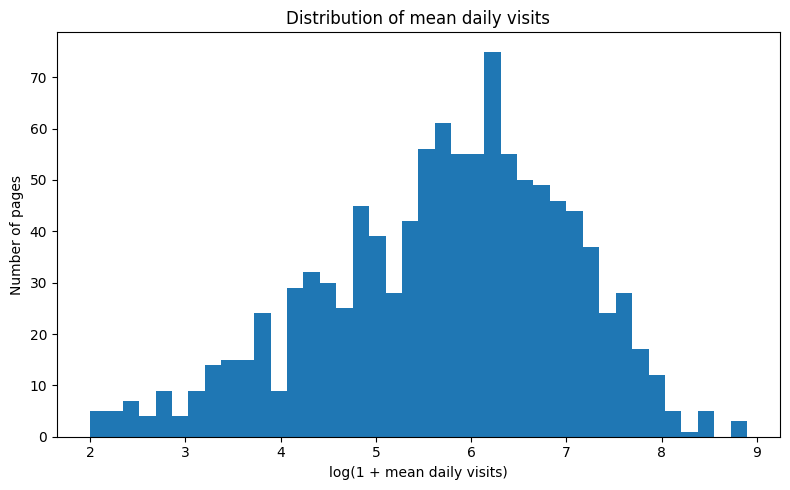

In [92]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(node_df["mean_visits"]), bins=40)
plt.xlabel("log(1 + mean daily visits)")
plt.ylabel("Number of pages")
plt.title("Distribution of mean daily visits")
plt.tight_layout()
plt.show()

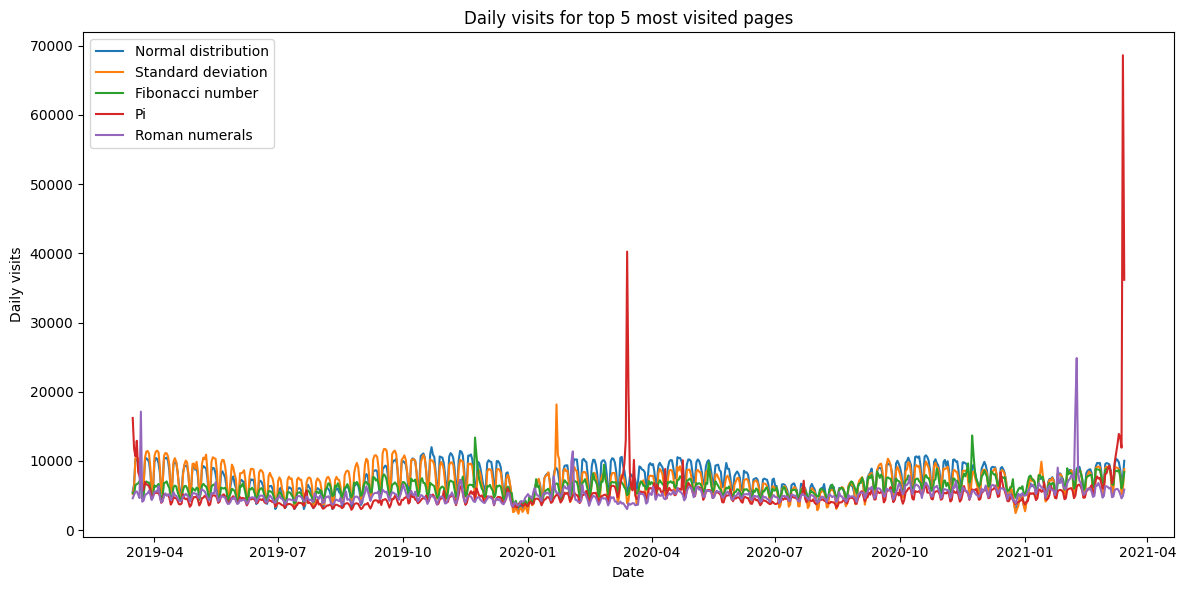

In [93]:
top_visit_pages = node_df.nlargest(5, "mean_visits")

plt.figure(figsize=(12, 6))

for _, row in top_visit_pages.iterrows():
    node = int(row["node"])
    plt.plot(dates, visits[:, node], label=row["title"])

plt.xlabel("Date")
plt.ylabel("Daily visits")
plt.title("Daily visits for top 5 most visited pages")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Centrality vs Attention

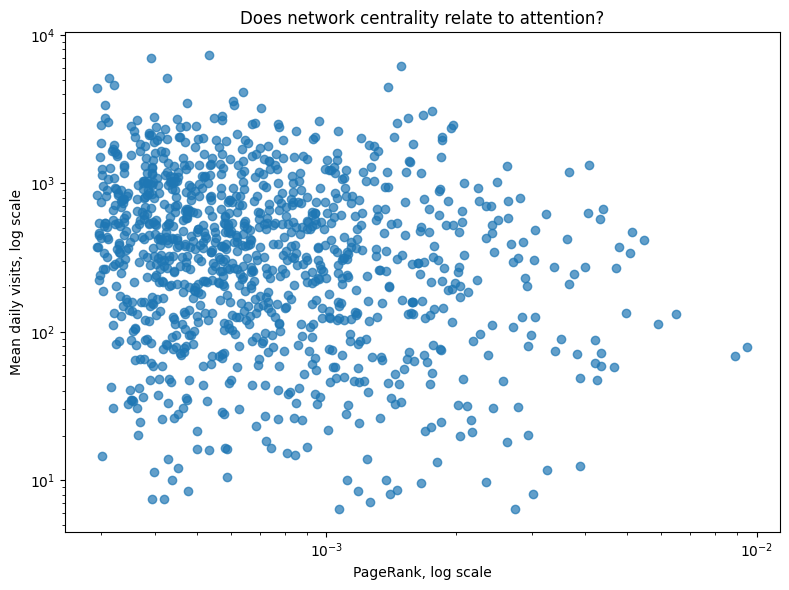

,pagerank,mean_visits,total_visits,in_degree,weighted_in_degree
pagerank,1.000000,-0.128585,-0.128585,0.139236,0.139847
mean_visits,-0.128585,1.000000,1.000000,0.157642,0.187616
total_visits,-0.128585,1.000000,1.000000,0.157642,0.187616
in_degree,0.139236,0.157642,0.157642,1.000000,0.952544
weighted_in_degree,0.139847,0.187616,0.187616,0.952544,1.000000


In [94]:
plot_df = node_df[(node_df["pagerank"] > 0) & (node_df["mean_visits"] > 0)]

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["pagerank"], plot_df["mean_visits"], alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("PageRank, log scale")
plt.ylabel("Mean daily visits, log scale")
plt.title("Does network centrality relate to attention?")
plt.tight_layout()
plt.show()

corr = plot_df[["pagerank", "mean_visits", "total_visits", "in_degree", "weighted_in_degree"]].corr()
corr

## 8. Gaussian Mixture Model Soft Clustering

For this project, the GMM uses preprocessing. The procedure is as follows:

1. use graph and visit magnitude features,
2. apply $\log(1+x)$ only to skewed nonnegative variables,
3. standardize the transformed variables,
4. fit GMMs for several values of $(k$),
5. choose $k$ from the BIC/AIC bend plus interpretability.

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import warnings

cluster_cols = [
    "in_degree",
    "out_degree",
    "weighted_in_degree",
    "weighted_out_degree",
    "pagerank",
    "mean_visits",
    "std_visits",
    "max_visits",
    "total_visits"
]

cluster_data = node_df[cluster_cols].copy()
cluster_data = cluster_data.replace([np.inf, -np.inf], np.nan).fillna(0)

# x* = log(1 + x)
# This is used only for nonnegative skewed features.
for col in cluster_cols:
    if cluster_data[col].min() >= 0:
        cluster_data[col] = np.log1p(cluster_data[col])

# Drop only truly constant columns.
stds = cluster_data.std(axis=0)
nonconstant_cols = stds[stds > 1e-12].index.tolist()
dropped_cols = sorted(set(cluster_cols) - set(nonconstant_cols))

print("Dropped columns:", dropped_cols)

cluster_data = cluster_data[nonconstant_cols]

# Standardize:
# z = (x - mean) / standard deviation
scaler = StandardScaler()
Z = scaler.fit_transform(cluster_data)

print("Any NaN?", np.isnan(Z).any())
print("Any inf?", np.isinf(Z).any())
print("Max absolute z-score:", np.abs(Z).max())

display(pd.Series(np.abs(Z).max(axis=0), index=nonconstant_cols).sort_values(ascending=False))

bic_rows = []
models = {}

for k in range(2, 11):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        reg_covar=1e-4,
        n_init=10,
        init_params="kmeans",
        random_state=42,
        max_iter=500
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        gmm.fit(Z)

    bic_rows.append({
        "k": k,
        "bic": gmm.bic(Z),
        "aic": gmm.aic(Z),
        "converged": gmm.converged_,
        "n_iter": gmm.n_iter_,
        "covariance_type": "full"
    })

    models[k] = gmm

bic_df = pd.DataFrame(bic_rows).sort_values("k")
bic_df

Dropped columns: []
Any NaN? False
Any inf? False
Max absolute z-score: 9.669182036547195


pagerank               9.669182
max_visits             4.478353
weighted_in_degree     4.470213
in_degree              4.436247
std_visits             4.158077
total_visits           2.950300
mean_visits            2.873571
out_degree             2.772984
weighted_out_degree    2.559288
dtype: float64

,k,bic,aic,converged,n_iter,covariance_type
0,2,2653.666579,2111.550390,True,11,full
1,3,1588.015561,772.354505,True,20,full
2,4,1094.257829,5.051907,True,25,full
3,5,1106.965332,-255.785456,True,29,full
4,6,1125.368865,-510.926788,True,28,full
5,7,1163.397004,-746.443516,True,71,full
6,8,1421.070451,-762.314934,True,47,full
7,9,1571.932841,-884.997411,True,47,full
8,10,1687.627217,-1042.847901,True,40,full


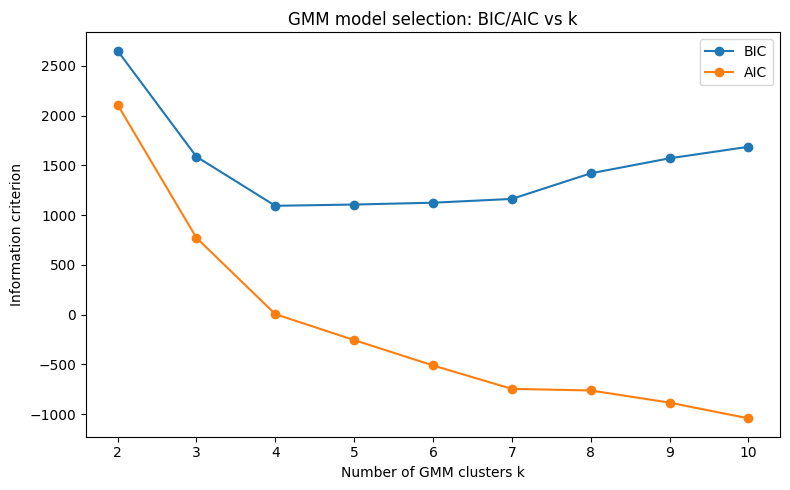

,k,bic,aic,converged,n_iter,covariance_type
0,2,2653.666579,2111.550390,True,11,full
1,3,1588.015561,772.354505,True,20,full
2,4,1094.257829,5.051907,True,25,full
3,5,1106.965332,-255.785456,True,29,full
4,6,1125.368865,-510.926788,True,28,full
5,7,1163.397004,-746.443516,True,71,full
6,8,1421.070451,-762.314934,True,47,full
7,9,1571.932841,-884.997411,True,47,full
8,10,1687.627217,-1042.847901,True,40,full


In [96]:
plt.figure(figsize=(8, 5))
plt.plot(bic_df["k"], bic_df["bic"], marker="o", label="BIC")
plt.plot(bic_df["k"], bic_df["aic"], marker="o", label="AIC")
plt.xlabel("Number of GMM clusters k")
plt.ylabel("Information criterion")
plt.title("GMM model selection: BIC/AIC vs k")
plt.legend()
plt.tight_layout()
plt.show()

bic_df

In [97]:

chosen_k = 5

best_gmm = models[chosen_k]

probs = best_gmm.predict_proba(Z)
labels = best_gmm.predict(Z)

node_df["gmm_cluster"] = labels
node_df["cluster_confidence"] = probs.max(axis=1)
old_prob_cols = [c for c in node_df.columns if c.startswith("p_cluster_")]
node_df = node_df.drop(columns=old_prob_cols, errors="ignore")

for j in range(chosen_k):
    node_df[f"p_cluster_{j}"] = probs[:, j]

print("Chosen k:", chosen_k)
print("Mean confidence:", node_df["cluster_confidence"].mean())

node_df[["title", "gmm_cluster", "cluster_confidence", "pagerank", "mean_visits"]].head()

Chosen k: 5
Mean confidence: 0.9167753754017907


,title,gmm_cluster,cluster_confidence,pagerank,mean_visits
0,Mathematics,3,1.0,0.000294,4367.558140
1,Number theory,3,1.0,0.000294,839.091655
2,Algebra,3,1.0,0.000299,1863.001368
3,Geometry,3,1.0,0.000301,1249.124487
4,Calculus,3,1.0,0.000300,2482.020520


Though losing .005 confidence is relevant, 5 groups allows for further and easier interpretation, with diversification across topics more seen.

## 9. GMM Cluster Diagnostics

In [98]:
cluster_summary = (
    node_df
    .groupby("gmm_cluster")
    .agg(
        n_pages=("node", "count"),
        avg_pagerank=("pagerank", "mean"),
        avg_in_degree=("in_degree", "mean"),
        avg_out_degree=("out_degree", "mean"),
        avg_mean_visits=("mean_visits", "mean"),
        avg_total_visits=("total_visits", "mean"),
        avg_confidence=("cluster_confidence", "mean")
    )
    .sort_values("avg_pagerank", ascending=False)
)

cluster_summary

,n_pages,avg_pagerank,avg_in_degree,avg_out_degree,avg_mean_visits,avg_total_visits,avg_confidence
gmm_cluster,,,,,,,
0,84,0.002653,30.833333,8.238095,484.954091,354501.440476,0.942405
4,248,0.001193,17.447581,1.794355,290.593360,212423.745968,0.949773
1,278,0.000958,30.097122,13.611511,599.217786,438028.201439,0.903783
2,300,0.000524,33.000000,46.736667,786.706731,575082.620000,0.894096
3,158,0.000366,11.993671,51.500000,849.614097,621067.905063,0.917277


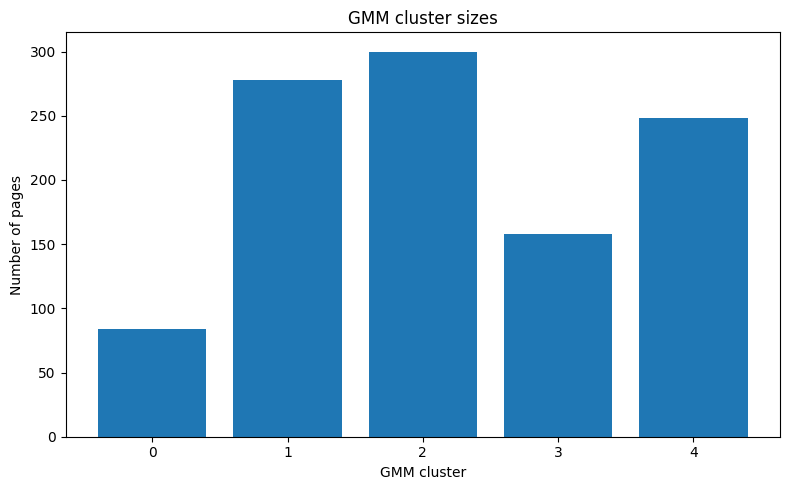

gmm_cluster
0     84
1    278
2    300
3    158
4    248
Name: count, dtype: int64

In [99]:
cluster_counts = node_df["gmm_cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel("GMM cluster")
plt.ylabel("Number of pages")
plt.title("GMM cluster sizes")
plt.tight_layout()
plt.show()

cluster_counts

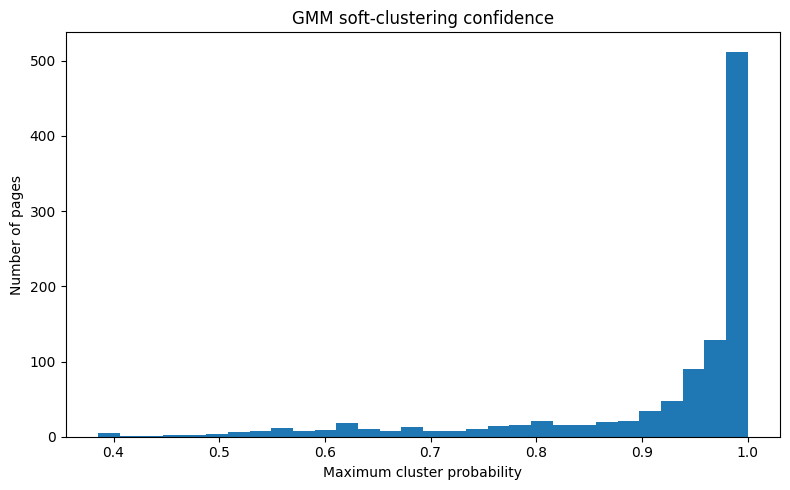

In [100]:
plt.figure(figsize=(8, 5))
plt.hist(node_df["cluster_confidence"], bins=30)
plt.xlabel("Maximum cluster probability")
plt.ylabel("Number of pages")
plt.title("GMM soft-clustering confidence")
plt.tight_layout()
plt.show()

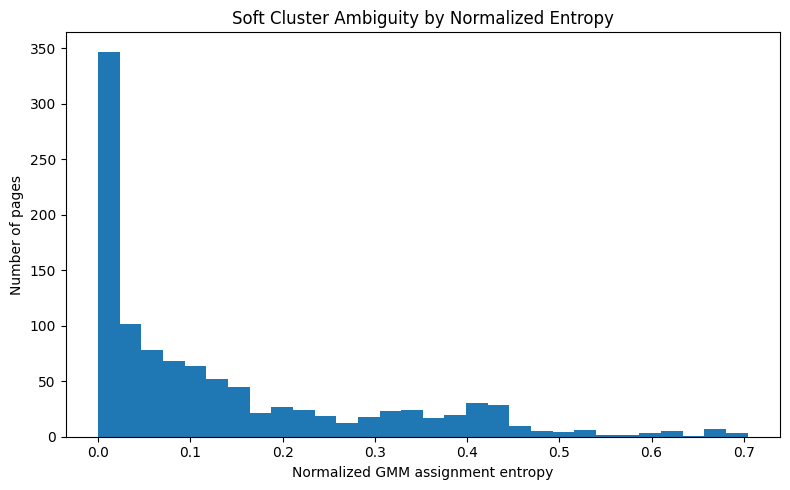

In [101]:
prob_cols = [col for col in node_df.columns if col.startswith("p_cluster_")]
P = node_df[prob_cols].to_numpy(dtype=float)

node_df["cluster_confidence"] = P.max(axis=1)

eps = 1e-12
entropy = -(P * np.log(P + eps)).sum(axis=1)
node_df["cluster_entropy"] = entropy
node_df["cluster_entropy_normalized"] = entropy / np.log(chosen_k)

plt.figure(figsize=(8, 5))
plt.hist(node_df["cluster_entropy_normalized"], bins=30)
plt.xlabel("Normalized GMM assignment entropy")
plt.ylabel("Number of pages")
plt.title("Soft Cluster Ambiguity by Normalized Entropy")
plt.tight_layout()
plt.show()

In [102]:
top_pages_by_cluster = (
    node_df
    .sort_values(["gmm_cluster", "pagerank"], ascending=[True, False])
    .groupby("gmm_cluster")
    .head(5)
    [["gmm_cluster", "title", "pagerank", "mean_visits", "in_degree", "out_degree", "cluster_confidence"]]
)

top_pages_by_cluster

,gmm_cluster,title,pagerank,mean_visits,in_degree,out_degree,cluster_confidence
996,0,Rotations in 4-dimensional Euclidean space,0.009516,78.860465,14,0,1.000000
989,0,24-cell,0.008917,68.205198,29,1,1.000000
906,0,Symmetric relation,0.006492,132.688098,25,3,1.000000
980,0,Branch point,0.005890,112.139535,26,0,1.000000
976,0,Queue (abstract data type),0.005472,414.634747,25,0,0.999996
768,1,Constant function,0.002045,170.716826,50,13,0.931224
796,1,Eigenvalues and eigenvectors,0.001973,2475.766074,99,8,0.994078
838,1,Antisymmetric relation,0.001955,193.455540,20,5,0.568258
562,1,Hyperbola,0.001920,755.477428,40,9,0.561593
857,1,Monomial,0.001914,190.547196,24,6,0.738846


In [103]:
ambiguous_pages = (
    node_df
    .sort_values("cluster_confidence")
    [["title", "gmm_cluster", "cluster_confidence", "cluster_entropy_normalized", "pagerank", "mean_visits"]]
    .head(10)
)

ambiguous_pages

,title,gmm_cluster,cluster_confidence,cluster_entropy_normalized,pagerank,mean_visits
581,Even and odd functions,4,0.385413,0.704047,0.000617,452.355677
407,Right angle,2,0.385810,0.680696,0.000701,375.623803
626,Field extension,1,0.391139,0.680236,0.000830,165.248974
112,Harmonic analysis,1,0.396150,0.701623,0.000464,185.502052
150,Model of computation,1,0.402726,0.663454,0.000353,137.554036
584,Fixed point (mathematics),4,0.420113,0.661385,0.000742,231.155951
551,Square (algebra),4,0.444875,0.668964,0.000867,458.001368
770,Heaviside step function,1,0.460580,0.664202,0.000626,711.525308
356,Rule of inference,1,0.466655,0.663002,0.000427,271.099863
570,Radius of convergence,2,0.471328,0.665461,0.000669,253.030096


## 10. SVD Graph Embedding

The SVD components are latent graph directions. They should not be automatically named as subjects like "algebra" or "geometry"; instead, interpret them by inspecting which pages have the largest positive and negative values.

In [104]:

A_binary = coo_matrix(
    (np.ones(len(edges), dtype=float), (edges[:, 0], edges[:, 1])),
    shape=(N, N)
).tocsr()

row_sums = np.asarray(A_binary.sum(axis=1)).ravel()
row_sums_safe = row_sums.copy()
row_sums_safe[row_sums_safe == 0] = 1.0

A_norm = A_binary.multiply(1 / row_sums_safe[:, None])

print("A_norm shape:", A_norm.shape)
print("A_norm nonzeros:", A_norm.nnz)
print("A_norm max:", A_norm.max())
print("Isolated rows:", int((row_sums == 0).sum()))

n_components = 20

svd = TruncatedSVD(
    n_components=n_components,
    algorithm="randomized",
    n_iter=10,
    random_state=42
)

svd_features = svd.fit_transform(A_norm)

svd_cols = [f"svd_{i+1}" for i in range(svd_features.shape[1])]

svd_df = pd.DataFrame(svd_features, columns=svd_cols)
svd_df["node"] = range(N)

# Avoid duplicate SVD columns if rerunning.
node_df = node_df.drop(columns=[c for c in node_df.columns if c.startswith("svd_")], errors="ignore")
node_df = node_df.merge(svd_df, on="node")

explained = pd.DataFrame({
    "component": svd_cols,
    "explained_variance_ratio": svd.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(svd.explained_variance_ratio_)
})

explained.head(10)

A_norm shape: (1068, 1068)
A_norm nonzeros: 27079
A_norm max: 1.0
Isolated rows: 103


/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


,component,explained_variance_ratio,cumulative_explained_variance
0,svd_1,0.017951,0.017951
1,svd_2,0.015157,0.033108
2,svd_3,0.015028,0.048137
3,svd_4,0.012810,0.060947
4,svd_5,0.011607,0.072554
5,svd_6,0.011535,0.084089
6,svd_7,0.011318,0.095407
7,svd_8,0.010553,0.105959
8,svd_9,0.009143,0.115102
9,svd_10,0.010734,0.125836


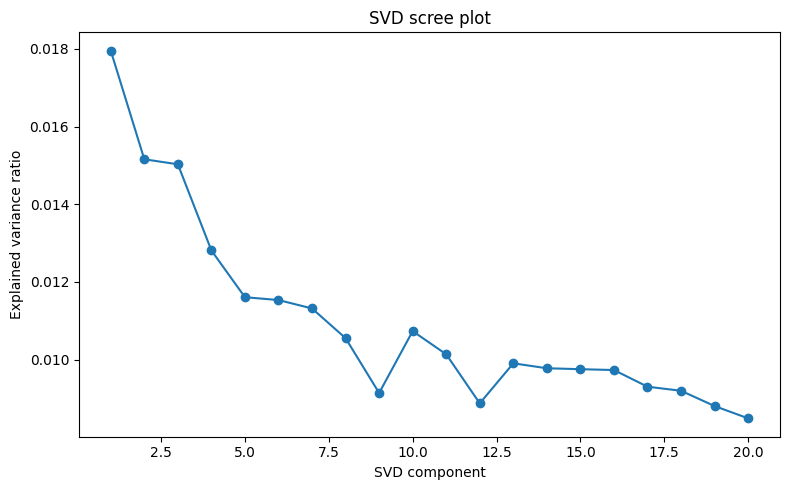

In [105]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(svd.explained_variance_ratio_) + 1),
    svd.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("SVD component")
plt.ylabel("Explained variance ratio")
plt.title("SVD scree plot")
plt.tight_layout()
plt.show()

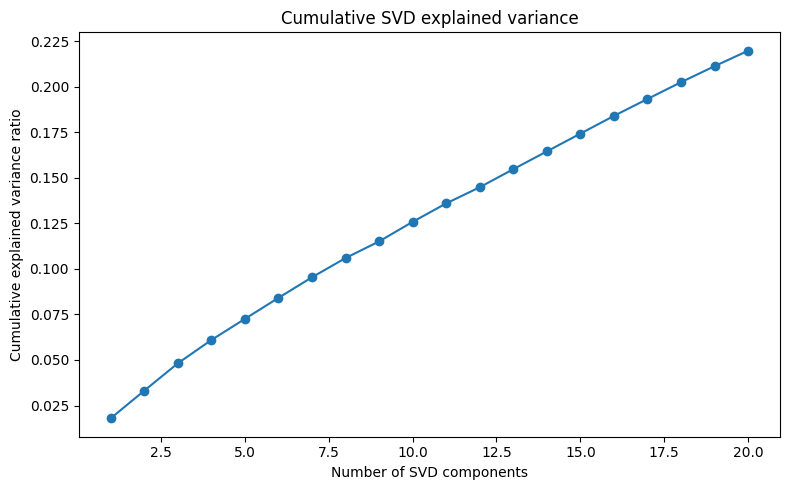

In [106]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(svd.explained_variance_ratio_) + 1),
    np.cumsum(svd.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of SVD components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Cumulative SVD explained variance")
plt.tight_layout()
plt.show()

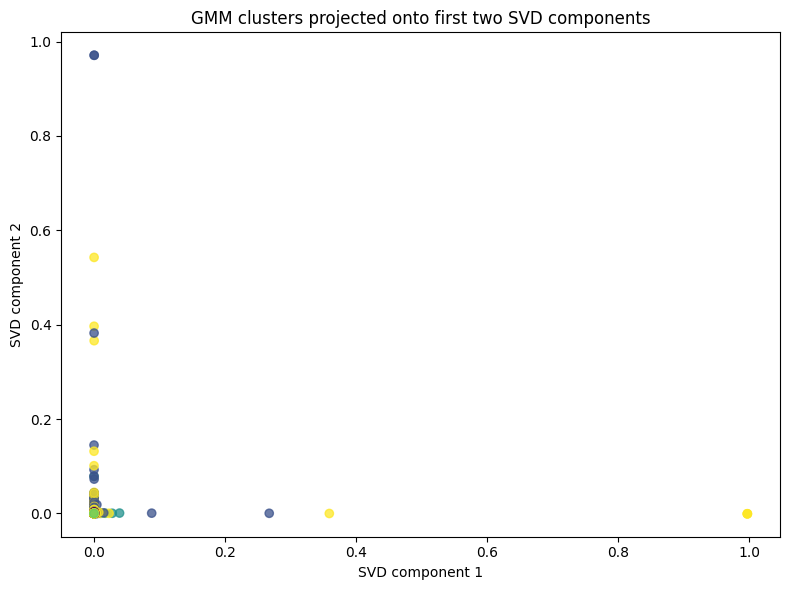

In [107]:
plt.figure(figsize=(8, 6))
plt.scatter(
    node_df["svd_1"],
    node_df["svd_2"],
    c=node_df["gmm_cluster"],
    alpha=0.75
)
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("GMM clusters projected onto first two SVD components")
plt.tight_layout()
plt.show()

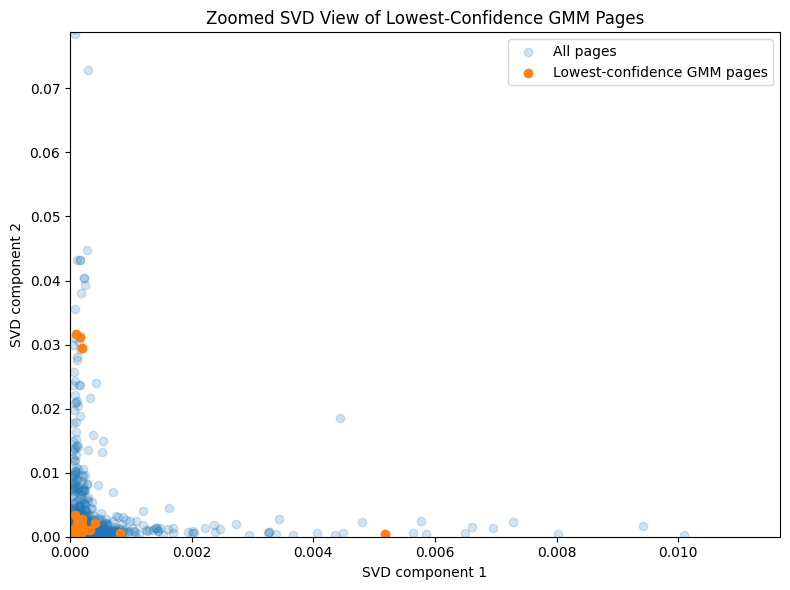

In [108]:
x = node_df["svd_1"]
y = node_df["svd_2"]

x_low, x_high = x.quantile([0.01, 0.99])
y_low, y_high = y.quantile([0.01, 0.99])

low_confidence_pages = node_df.nsmallest(25, "cluster_confidence")

plt.figure(figsize=(8, 6))
plt.scatter(
    node_df["svd_1"],
    node_df["svd_2"],
    alpha=0.20,
    label="All pages"
)
plt.scatter(
    low_confidence_pages["svd_1"],
    low_confidence_pages["svd_2"],
    alpha=0.95,
    label="Lowest-confidence GMM pages"
)

plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)

plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("Zoomed SVD View of Lowest-Confidence GMM Pages")
plt.legend()
plt.tight_layout()
plt.show()

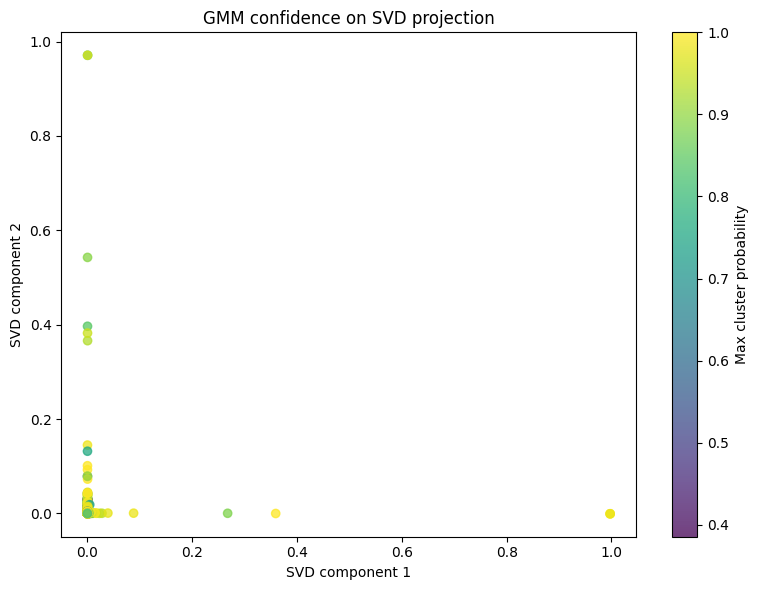

In [109]:
plt.figure(figsize=(8, 6))
plt.scatter(
    node_df["svd_1"],
    node_df["svd_2"],
    c=node_df["cluster_confidence"],
    alpha=0.75
)
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("GMM confidence on SVD projection")
plt.colorbar(label="Max cluster probability")
plt.tight_layout()
plt.show()

## 10.5. Interpreting SVD

- If GMM clusters differ in their SVD component averages, then the clusters reflect different latent graph positions.
- If low-confidence GMM pages sit between clusters in SVD space, then they can be interpreted as bridge or overlapping pages.
- If SVD features improve regression performance, then latent graph structure helps explain page attention.

In [110]:
def show_svd_component(component, n=10):
    col = f"svd_{component}"

    positive = (
        node_df
        .sort_values(col, ascending=False)
        [["title", col, "pagerank", "mean_visits", "gmm_cluster", "cluster_confidence"]]
        .head(n)
    )

    negative = (
        node_df
        .sort_values(col, ascending=True)
        [["title", col, "pagerank", "mean_visits", "gmm_cluster", "cluster_confidence"]]
        .head(n)
    )

    print(f"Top positive pages for {col}:")
    display(positive)

    print(f"Top negative pages for {col}:")
    display(negative)

show_svd_component(1)
show_svd_component(2)
show_svd_component(3)

Top positive pages for svd_1:


,title,svd_1,pagerank,mean_visits,gmm_cluster,cluster_confidence
890,Karush–Kuhn–Tucker conditions,0.997377,0.001304,567.696306,4,0.998613
993,Jensen's inequality,0.997377,0.002352,700.738714,4,0.997405
1009,Transportation theory (mathematics),0.997377,0.001072,148.173735,4,0.979179
832,Hungarian algorithm,0.359269,0.000578,373.020520,4,0.998064
889,Nonlinear programming,0.267546,0.001852,220.968536,1,0.882170
310,Lagrange multiplier,0.088117,0.001049,1183.433653,1,0.981220
235,Convex set,0.039086,0.000450,370.853625,2,0.976396
233,Linear programming,0.027878,0.000394,1271.696306,2,0.933893
655,Bounded function,0.023109,0.000627,205.905609,4,0.948054
102,Mathematical optimization,0.017322,0.000437,914.932969,3,0.975150


Top negative pages for svd_1:


,title,svd_1,pagerank,mean_visits,gmm_cluster,cluster_confidence
735,Blum's speedup theorem,-0.000018,0.000437,10.097127,4,0.999989
1029,Five lemma,-0.000015,0.000772,40.339261,4,0.982064
1028,Snake lemma,-0.000002,0.000359,64.482900,4,0.859902
726,Time hierarchy theorem,-0.000002,0.000429,33.352941,1,0.861209
1067,Cache replacement policies,0.000000,0.000296,459.585499,3,0.821425
1008,Iterated integral,0.000000,0.001122,32.155951,4,0.990614
1007,Data visualization,0.000000,0.000835,553.618331,4,0.999579
1006,UTM theorem,0.000000,0.001263,7.124487,4,1.000000
1005,Harmonic conjugate,0.000000,0.000928,60.246238,4,0.991201
1004,Feasible region,0.000000,0.001549,132.794802,4,0.999907


Top positive pages for svd_2:


...

,title,svd_2,pagerank,mean_visits,gmm_cluster,cluster_confidence
993,Jensen's inequality,-0.000697,0.002352,700.738714,4,0.997405
890,Karush–Kuhn–Tucker conditions,-0.000697,0.001304,567.696306,4,0.998613
1009,Transportation theory (mathematics),-0.000697,0.001072,148.173735,4,0.979179
895,Gauss–Seidel method,-0.000145,0.000649,379.004104,4,0.994229
894,Jacobi method,-0.000058,0.000457,276.202462,1,0.994472
832,Hungarian algorithm,-0.000044,0.000578,373.020520,4,0.998064
797,Banach space,0.000000,0.002680,391.138167,4,0.999845
997,Stirling number,0.000000,0.004354,72.194254,0,0.999095
996,Rotations in 4-dimensional Euclidean space,0.000000,0.009516,78.860465,0,1.000000
995,Triangular array,0.000000,0.002622,17.990424,4,0.999771


Top positive pages for svd_3:


,title,svd_3,pagerank,mean_visits,gmm_cluster,cluster_confidence
911,Dirichlet problem,0.978245,0.000912,74.165527,4,0.953366
913,Poisson's equation,0.978245,0.002431,525.502052,4,0.985224
912,Elliptic operator,0.558089,0.001047,58.140903,1,0.996459
914,Hyperbolic partial differential equation,0.557876,0.001781,143.147743,1,0.624068
566,Parabolic partial differential equation,0.265328,0.000403,129.489740,3,0.763855
850,Harmonic function,0.214942,0.001822,306.162791,4,0.929431
873,Crank–Nicolson method,0.100667,0.001987,214.716826,4,0.979983
652,Linear differential equation,0.072828,0.001736,471.099863,1,0.989791
369,Ellipse,0.052911,0.000567,1359.299590,2,0.920391
329,Laplace's equation,0.049442,0.000378,609.419973,3,0.953261


Top negative pages for svd_3:


,title,svd_3,pagerank,mean_visits,gmm_cluster,cluster_confidence
936,Additive function,-0.008899,0.000442,26.344733,1,0.962001
904,Möbius function,-0.008899,0.001579,159.146375,1,0.811727
903,Möbius inversion formula,-0.004868,0.001014,76.161423,4,0.890062
908,Dirichlet character,-0.003492,0.000699,65.941176,4,0.840761
909,Legendre symbol,-0.003309,0.001587,131.377565,1,0.950227
840,Least common multiple,-0.003126,0.002825,795.927497,4,0.929049
572,Dirichlet series,-0.001139,0.001058,120.381669,1,0.985023
756,1,-0.001044,0.001852,1494.901505,4,0.759117
631,Diffie–Hellman key exchange,-0.000733,0.000640,1421.653899,4,0.998914
621,Euler's totient function,-0.000707,0.001058,797.324213,1,0.997670


In [111]:
svd_cluster_means = (
    node_df
    .groupby("gmm_cluster")[svd_cols[:5]]
    .mean()
)

svd_cluster_means

,svd_1,svd_2,svd_3,svd_4,svd_5
gmm_cluster,,,,,
0,0.000287,0.002152,0.000387,0.002738,0.004413
1,0.001839,0.013160,0.005078,0.009611,0.006432
2,0.000474,0.002395,0.001078,0.003217,0.003367
3,0.000409,0.002435,0.002357,0.004742,0.002607
4,0.013918,0.008608,0.009739,0.007074,0.011345


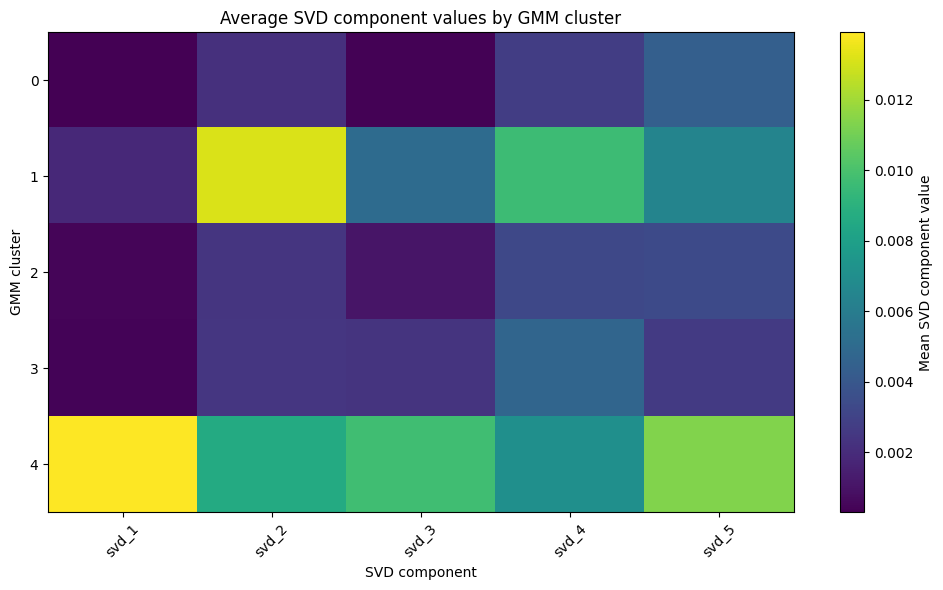

In [112]:
plt.figure(figsize=(10, 6))
plt.imshow(svd_cluster_means, aspect="auto")
plt.colorbar(label="Mean SVD component value")
plt.xticks(range(len(svd_cols[:5])), svd_cols[:5], rotation=45)
plt.yticks(range(len(svd_cluster_means.index)), svd_cluster_means.index)
plt.xlabel("SVD component")
plt.ylabel("GMM cluster")
plt.title("Average SVD component values by GMM cluster")
plt.tight_layout()
plt.show()

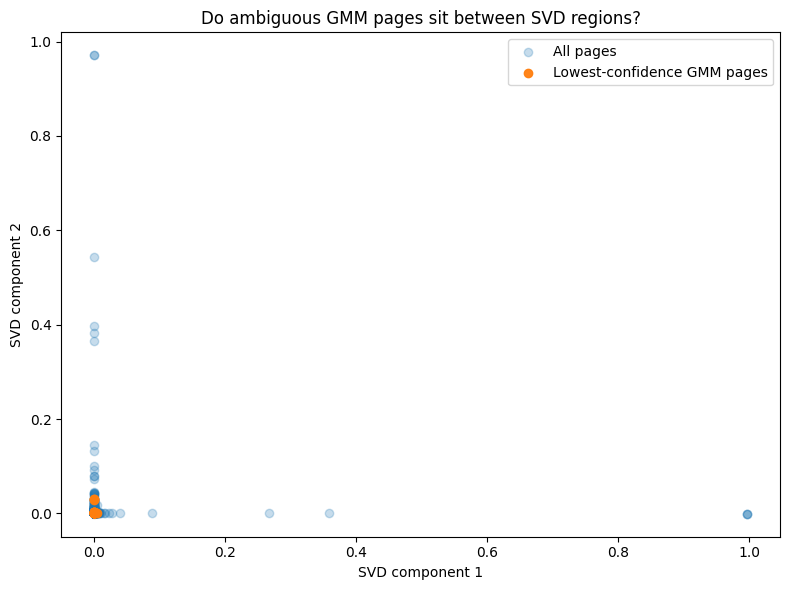

,title,gmm_cluster,cluster_confidence,cluster_entropy,svd_1,svd_2,pagerank,mean_visits
581,Even and odd functions,4,0.385413,1.133120,0.000143,0.002056,0.000617,452.355677
407,Right angle,2,0.385810,1.095538,0.000118,0.000456,0.000701,375.623803
626,Field extension,1,0.391139,1.094798,0.000138,0.002149,0.000830,165.248974
112,Harmonic analysis,1,0.396150,1.129218,0.000244,0.001026,0.000464,185.502052
150,Model of computation,1,0.402726,1.067788,0.000057,0.000271,0.000353,137.554036
584,Fixed point (mathematics),4,0.420113,1.064458,0.000113,0.001035,0.000742,231.155951
551,Square (algebra),4,0.444875,1.076656,0.000198,0.029476,0.000867,458.001368
770,Heaviside step function,1,0.460580,1.068992,0.000412,0.002105,0.000626,711.525308
356,Rule of inference,1,0.466655,1.067060,0.000053,0.000748,0.000427,271.099863
570,Radius of convergence,2,0.471328,1.071018,0.000108,0.002083,0.000669,253.030096


In [113]:
low_confidence_pages = node_df.nsmallest(25, "cluster_confidence")

plt.figure(figsize=(8, 6))
plt.scatter(
    node_df["svd_1"],
    node_df["svd_2"],
    alpha=0.25,
    label="All pages"
)
plt.scatter(
    low_confidence_pages["svd_1"],
    low_confidence_pages["svd_2"],
    alpha=0.95,
    label="Lowest-confidence GMM pages"
)
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("Do ambiguous GMM pages sit between SVD regions?")
plt.legend()
plt.tight_layout()
plt.show()

low_confidence_pages[
    ["title", "gmm_cluster", "cluster_confidence", "cluster_entropy", "svd_1", "svd_2", "pagerank", "mean_visits"]
]

SVD was used to create a low-dimensional representation of the directed graph. I did not interpret the SVD components as automatic subject labels. Instead, I inspected the pages with the largest positive and negative values on each component. This allowed me to describe what each latent direction seemed to separate. I then compared the SVD representation to the GMM clusters. We see high cluster entropy, and small differences in SVD, however, each vector does seem to encode topics, SVD 1 does seem to focus on Optimization, SVD2 on Number Theory, and SVD3 on differential equations.

## 11. Regression: Can Graph Structure Predict Page Attention?

The regression target is:

$$
y_i=\log(1+\text{mean visits}_i)
$$

This makes the target less dominated by a few extremely popular pages.

The model comparisons are:

1. PageRank only.
2. Centrality features only.
3. SVD features only.
4. Centrality plus SVD features.

This tests whether latent graph structure adds predictive value beyond simple centrality.

In [114]:
target = np.log1p(node_df["mean_visits"])

graph_feature_cols = [
    "in_degree",
    "out_degree",
    "weighted_in_degree",
    "weighted_out_degree",
    "pagerank"
]

svd_feature_cols = svd_cols
combined_feature_cols = graph_feature_cols + svd_feature_cols

def fit_ridge_regression(feature_cols, name):
    X = node_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    y = target

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-4, 4, 30)))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, pred) ** 0.5

    return {
        "model": name,
        "r2": r2_score(y_test, pred),
        "mae": mean_absolute_error(y_test, pred),
        "rmse": rmse,
        "chosen_alpha": model.named_steps["ridge"].alpha_,
        "fitted_model": model,
        "feature_cols": feature_cols,
        "X_test": X_test,
        "y_test": y_test,
        "pred": pred
    }

results = [
    fit_ridge_regression(["pagerank"], "pagerank_only"),
    fit_ridge_regression(graph_feature_cols, "centrality_only"),
    fit_ridge_regression(svd_feature_cols, "svd_only"),
    fit_ridge_regression(combined_feature_cols, "centrality_plus_svd")
]

regression_results = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ["fitted_model", "feature_cols", "X_test", "y_test", "pred"]}
    for row in results
])

regression_results.sort_values("r2", ascending=False)

/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manankk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

,model,r2,mae,rmse,chosen_alpha
3,centrality_plus_svd,0.241828,0.864085,1.097960,221.221629
1,centrality_only,0.188971,0.908360,1.135588,62.101694
2,svd_only,0.045114,0.991690,1.232192,221.221629
0,pagerank_only,0.020596,1.005641,1.247911,32.903446


In [115]:
best_result = max(results, key=lambda d: d["r2"])
best_model = best_result["fitted_model"]
best_cols = best_result["feature_cols"]
y_test = best_result["y_test"]
pred = best_result["pred"]
resid = y_test - pred

print("Best model:", best_result["model"])
print("R^2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)

Best model: centrality_plus_svd
R^2: 0.24182826714910055
MAE: 0.8640849969485814
RMSE: 1.0979596302104866


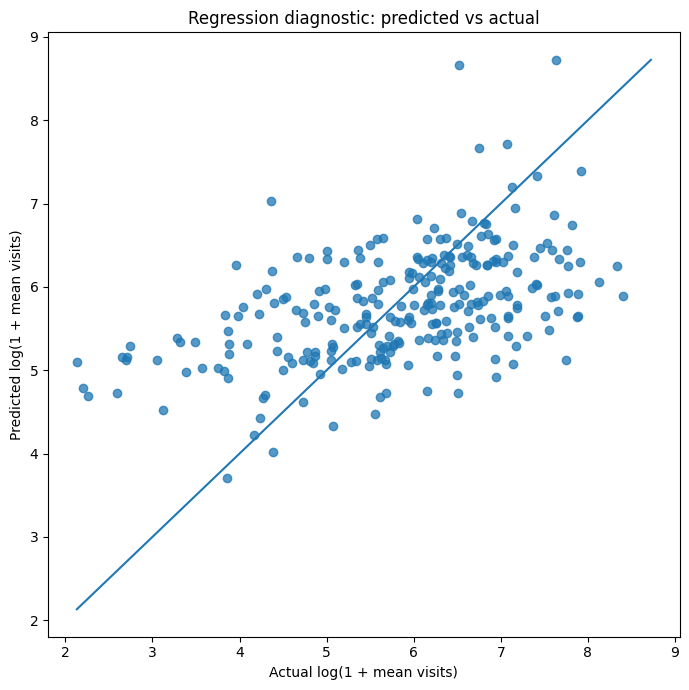

In [116]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.75)

low = min(y_test.min(), pred.min())
high = max(y_test.max(), pred.max())

plt.plot([low, high], [low, high])
plt.xlabel("Actual log(1 + mean visits)")
plt.ylabel("Predicted log(1 + mean visits)")
plt.title("Regression diagnostic: predicted vs actual")
plt.tight_layout()
plt.show()

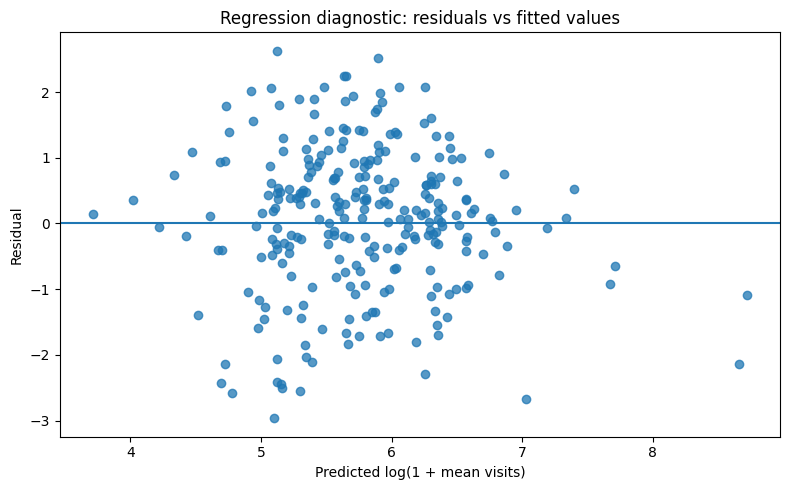

In [117]:
plt.figure(figsize=(8, 5))
plt.scatter(pred, resid, alpha=0.75)
plt.axhline(0)
plt.xlabel("Predicted log(1 + mean visits)")
plt.ylabel("Residual")
plt.title("Regression diagnostic: residuals vs fitted values")
plt.tight_layout()
plt.show()

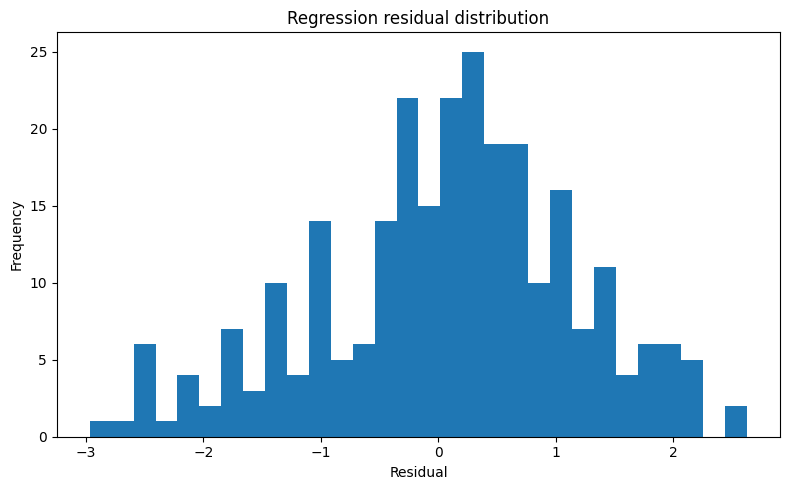

In [118]:
plt.figure(figsize=(8, 5))
plt.hist(resid, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Regression residual distribution")
plt.tight_layout()
plt.show()

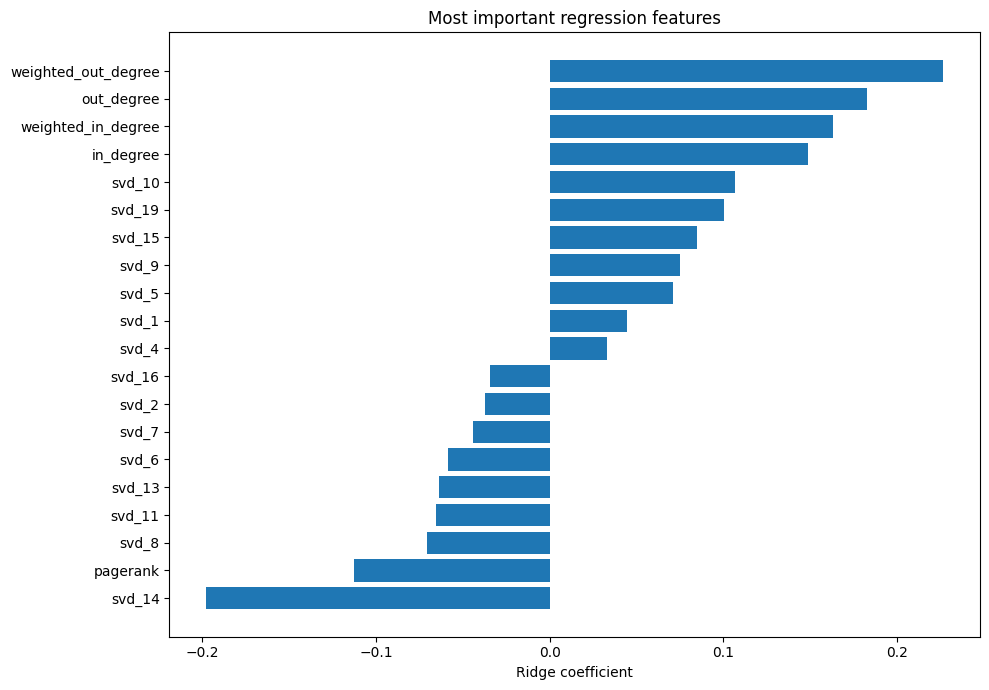

,feature,coefficient,abs_coefficient
3,weighted_out_degree,0.226609,0.226609
18,svd_14,-0.197778,0.197778
1,out_degree,0.182509,0.182509
2,weighted_in_degree,0.163363,0.163363
0,in_degree,0.148973,0.148973
4,pagerank,-0.112882,0.112882
14,svd_10,0.106879,0.106879
23,svd_19,0.100173,0.100173
19,svd_15,0.084655,0.084655
13,svd_9,0.075002,0.075002


In [119]:
coef_df = pd.DataFrame({
    "feature": best_cols,
    "coefficient": best_model.named_steps["ridge"].coef_
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_coef = coef_df.sort_values("abs_coefficient", ascending=False).head(20)
top_coef_plot = top_coef.sort_values("coefficient")

plt.figure(figsize=(10, 7))
plt.barh(top_coef_plot["feature"], top_coef_plot["coefficient"])
plt.xlabel("Ridge coefficient")
plt.title("Most important regression features")
plt.tight_layout()
plt.show()

top_coef.sort_values("abs_coefficient", ascending=False)

## 12. Final Diagnostic Summary

In [120]:
diagnostic_summary = pd.DataFrame({
    "check": [
        "Number of nodes",
        "Number of edges",
        "Isolated nodes",
        "Weakly connected components",
        "Strongly connected components",
        "Chosen GMM k",
        "Mean GMM confidence",
        "Pages with confidence < 0.60",
        "Mean cluster entropy",
        "Best regression model",
        "Best regression R^2",
        "Best regression RMSE"
    ],
    "value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        len(list(nx.isolates(G))),
        len(list(nx.weakly_connected_components(G))),
        len(list(nx.strongly_connected_components(G))),
        chosen_k,
        node_df["cluster_confidence"].mean(),
        int((node_df["cluster_confidence"] < 0.60).sum()),
        node_df["cluster_entropy"].mean(),
        best_result["model"],
        r2_score(y_test, pred),
        mean_squared_error(y_test, pred) ** 0.5
    ]
})

diagnostic_summary

,check,value
0,Number of nodes,1068
1,Number of edges,27079
2,Isolated nodes,0
3,Weakly connected components,1
4,Strongly connected components,1068
5,Chosen GMM k,5
6,Mean GMM confidence,0.916775
7,Pages with confidence < 0.60,50
8,Mean cluster entropy,0.218398
9,Best regression model,centrality_plus_svd


## 14. Save Final Outputs

In [121]:
outdir = Path("wiki_math_outputs")
outdir.mkdir(exist_ok=True)

node_df.to_csv(outdir / "nodes_enriched_with_diagnostics.csv", index=False)
edges_df.to_csv(outdir / "edges.csv", index=False)
cluster_summary.to_csv(outdir / "cluster_summary.csv")
top_pages_by_cluster.to_csv(outdir / "top_pages_by_cluster.csv", index=False)
ambiguous_pages.to_csv(outdir / "ambiguous_soft_cluster_pages.csv", index=False)
regression_results.to_csv(outdir / "regression_results.csv", index=False)
coef_df.to_csv(outdir / "ridge_coefficients.csv", index=False)
diagnostic_summary.to_csv(outdir / "diagnostic_summary.csv", index=False)
bic_df.to_csv(outdir / "gmm_bic_aic.csv", index=False)

print("Saved outputs to:", outdir.resolve())

Saved outputs to: /Users/manankk/Desktop/Year 2/Sem 2/CSCI 4022 - Advanced Data Science/Projects/wiki_math_outputs


In [122]:
# Save all major project plots as image files without displaying them

from pathlib import Path

plotdir = Path("wiki_math_outputs") / "plots"
plotdir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = plotdir / name
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.close()
    print(f"Saved {path}")

# 1. In-degree distribution
plt.figure(figsize=(8, 5))
plt.hist(node_df["in_degree"], bins=40)
plt.xlabel("In-degree")
plt.ylabel("Number of pages")
plt.title("In-degree distribution")
plt.tight_layout()
savefig("01_in_degree_distribution.png")

# 2. Out-degree distribution
plt.figure(figsize=(8, 5))
plt.hist(node_df["out_degree"], bins=40)
plt.xlabel("Out-degree")
plt.ylabel("Number of pages")
plt.title("Out-degree distribution")
plt.tight_layout()
savefig("02_out_degree_distribution.png")

# 3. Top PageRank pages
top_pr = node_df.nlargest(20, "pagerank").sort_values("pagerank")

plt.figure(figsize=(10, 7))
plt.barh(top_pr["title"], top_pr["pagerank"])
plt.xlabel("PageRank")
plt.title("Top 20 pages by PageRank")
plt.tight_layout()
savefig("03_top_20_pagerank.png")

# 4. PageRank vs in-degree
plt.figure(figsize=(8, 6))
plt.scatter(np.log1p(node_df["in_degree"]), np.log1p(node_df["pagerank"]), alpha=0.7)
plt.xlabel("log(1 + in-degree)")
plt.ylabel("log(1 + PageRank)")
plt.title("Log PageRank vs log in-degree")
plt.tight_layout()
savefig("04_log_pagerank_vs_log_indegree.png")

# 5. Mean visits distribution
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(node_df["mean_visits"]), bins=40)
plt.xlabel("log(1 + mean daily visits)")
plt.ylabel("Number of pages")
plt.title("Distribution of mean daily visits")
plt.tight_layout()
savefig("05_mean_daily_visits_distribution.png")

# 6. Top 5 visited pages over time
top_visit_pages = node_df.nlargest(5, "mean_visits")

plt.figure(figsize=(12, 6))
for _, row in top_visit_pages.iterrows():
    node = int(row["node"])
    plt.plot(dates, visits[:, node], label=row["title"])

plt.xlabel("Date")
plt.ylabel("Daily visits")
plt.title("Daily visits for top 5 most visited pages")
plt.legend()
plt.tight_layout()
savefig("06_top_5_visit_timeseries.png")

# 7. PageRank vs visits, log-log scale
plot_df = node_df[(node_df["pagerank"] > 0) & (node_df["mean_visits"] > 0)]

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["pagerank"], plot_df["mean_visits"], alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("PageRank, log scale")
plt.ylabel("Mean daily visits, log scale")
plt.title("Does network centrality relate to attention?")
plt.tight_layout()
savefig("07_pagerank_vs_mean_visits_loglog.png")

# 8. PageRank vs visits trendline
x_log = np.log1p(node_df["pagerank"].to_numpy(dtype=float))
y_log = np.log1p(node_df["mean_visits"].to_numpy(dtype=float))

m, b = np.polyfit(x_log, y_log, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x_log, y_log, alpha=0.7)
plt.plot(x_log, m * x_log + b)
plt.xlabel("log(1 + PageRank)")
plt.ylabel("log(1 + mean daily visits)")
plt.title("Log PageRank vs Log Mean Daily Visits with Trend Line")
plt.tight_layout()
savefig("08_pagerank_vs_visits_trendline.png")

# 9. GMM BIC/AIC
plt.figure(figsize=(8, 5))
plt.plot(bic_df["k"], bic_df["bic"], marker="o", label="BIC")
plt.plot(bic_df["k"], bic_df["aic"], marker="o", label="AIC")
plt.xlabel("Number of GMM clusters k")
plt.ylabel("Information criterion")
plt.title("GMM model selection: BIC/AIC vs k")
plt.legend()
plt.tight_layout()
savefig("09_gmm_bic_aic_vs_k.png")

# 10. GMM cluster sizes
cluster_counts = node_df["gmm_cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel("GMM cluster")
plt.ylabel("Number of pages")
plt.title("GMM cluster sizes")
plt.tight_layout()
savefig("10_gmm_cluster_sizes.png")

# 11. GMM confidence histogram
plt.figure(figsize=(8, 5))
plt.hist(node_df["cluster_confidence"], bins=30)
plt.xlabel("Maximum cluster probability")
plt.ylabel("Number of pages")
plt.title("GMM soft-clustering confidence")
plt.tight_layout()
savefig("11_gmm_cluster_confidence.png")

# 12. GMM entropy histogram, if available
if "cluster_entropy_normalized" in node_df.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(node_df["cluster_entropy_normalized"], bins=30)
    plt.xlabel("Normalized GMM assignment entropy")
    plt.ylabel("Number of pages")
    plt.title("Soft Cluster Ambiguity by Normalized Entropy")
    plt.tight_layout()
    savefig("12_gmm_normalized_entropy.png")

# 13. SVD scree plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(svd.explained_variance_ratio_) + 1),
    svd.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("SVD component")
plt.ylabel("Explained variance ratio")
plt.title("SVD scree plot")
plt.tight_layout()
savefig("13_svd_scree_plot.png")

# 14. Cumulative SVD explained variance
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(svd.explained_variance_ratio_) + 1),
    np.cumsum(svd.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of SVD components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Cumulative SVD explained variance")
plt.tight_layout()
savefig("14_svd_cumulative_explained_variance.png")

# 15. SVD projection colored by GMM cluster
plt.figure(figsize=(8, 6))
plt.scatter(
    node_df["svd_1"],
    node_df["svd_2"],
    c=node_df["gmm_cluster"],
    alpha=0.75
)
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("GMM clusters projected onto first two SVD components")
plt.tight_layout()
savefig("15_svd_gmm_cluster_projection.png")

# 16. SVD projection colored by GMM confidence
plt.figure(figsize=(8, 6))
plt.scatter(
    node_df["svd_1"],
    node_df["svd_2"],
    c=node_df["cluster_confidence"],
    alpha=0.75
)
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("GMM confidence on SVD projection")
plt.colorbar(label="GMM confidence")
plt.tight_layout()
savefig("16_svd_gmm_confidence_projection.png")

# 17. Zoomed SVD confidence plot
x = node_df["svd_1"]
y = node_df["svd_2"]

x_low, x_high = x.quantile([0.01, 0.99])
y_low, y_high = y.quantile([0.01, 0.99])

plt.figure(figsize=(8, 6))
plt.scatter(
    node_df["svd_1"],
    node_df["svd_2"],
    c=node_df["cluster_confidence"],
    alpha=0.75
)
plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("GMM Confidence in Zoomed SVD Space")
plt.colorbar(label="GMM confidence")
plt.tight_layout()
savefig("17_zoomed_svd_gmm_confidence.png")

# 18. SVD component means by GMM cluster
svd_cluster_means = (
    node_df
    .groupby("gmm_cluster")[svd_cols[:5]]
    .mean()
)

plt.figure(figsize=(10, 6))
plt.imshow(svd_cluster_means, aspect="auto")
plt.colorbar(label="Mean SVD component value")
plt.xticks(range(len(svd_cols[:5])), svd_cols[:5], rotation=45)
plt.yticks(range(len(svd_cluster_means.index)), svd_cluster_means.index)
plt.xlabel("SVD component")
plt.ylabel("GMM cluster")
plt.title("Average SVD component values by GMM cluster")
plt.tight_layout()
savefig("18_svd_component_means_by_gmm_cluster.png")

# 19-21. Regression diagnostics, if best_result exists
if "best_result" in globals():
    y_test = best_result["y_test"]
    pred = best_result["pred"]
    resid = y_test - pred

    # Predicted vs actual
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, pred, alpha=0.75)

    low = min(y_test.min(), pred.min())
    high = max(y_test.max(), pred.max())

    plt.plot([low, high], [low, high])
    plt.xlabel("Actual log(1 + mean visits)")
    plt.ylabel("Predicted log(1 + mean visits)")
    plt.title("Regression diagnostic: predicted vs actual")
    plt.tight_layout()
    savefig("19_regression_predicted_vs_actual.png")

    # Residuals vs fitted
    plt.figure(figsize=(8, 5))
    plt.scatter(pred, resid, alpha=0.75)
    plt.axhline(0)
    plt.xlabel("Predicted log(1 + mean visits)")
    plt.ylabel("Residual")
    plt.title("Regression diagnostic: residuals vs fitted values")
    plt.tight_layout()
    savefig("20_regression_residuals_vs_fitted.png")

    # Residual distribution
    plt.figure(figsize=(8, 5))
    plt.hist(resid, bins=30)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title("Regression residual distribution")
    plt.tight_layout()
    savefig("21_regression_residual_distribution.png")

# 22. Regression coefficients, if available
if "coef_df" in globals():
    top_coef = coef_df.sort_values("abs_coefficient", ascending=False).head(20)
    top_coef_plot = top_coef.sort_values("coefficient")

    plt.figure(figsize=(10, 7))
    plt.barh(top_coef_plot["feature"], top_coef_plot["coefficient"])
    plt.xlabel("Ridge coefficient")
    plt.title("Most important regression features")
    plt.tight_layout()
    savefig("22_regression_feature_coefficients.png")

print(f"Done. Saved plots to: {plotdir.resolve()}")

Saved wiki_math_outputs/plots/01_in_degree_distribution.png
Saved wiki_math_outputs/plots/02_out_degree_distribution.png
Saved wiki_math_outputs/plots/03_top_20_pagerank.png
Saved wiki_math_outputs/plots/04_log_pagerank_vs_log_indegree.png
Saved wiki_math_outputs/plots/05_mean_daily_visits_distribution.png
Saved wiki_math_outputs/plots/06_top_5_visit_timeseries.png
Saved wiki_math_outputs/plots/07_pagerank_vs_mean_visits_loglog.png
Saved wiki_math_outputs/plots/08_pagerank_vs_visits_trendline.png
Saved wiki_math_outputs/plots/09_gmm_bic_aic_vs_k.png
Saved wiki_math_outputs/plots/10_gmm_cluster_sizes.png
Saved wiki_math_outputs/plots/11_gmm_cluster_confidence.png
Saved wiki_math_outputs/plots/12_gmm_normalized_entropy.png
Saved wiki_math_outputs/plots/13_svd_scree_plot.png
Saved wiki_math_outputs/plots/14_svd_cumulative_explained_variance.png
Saved wiki_math_outputs/plots/15_svd_gmm_cluster_projection.png
Saved wiki_math_outputs/plots/16_svd_gmm_confidence_projection.png
Saved wiki_math